In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_swiss_roll
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

from sklearn.manifold import MDS, TSNE

In [ ]:
X, t = make_swiss_roll(n_samples=1500, noise=0.2, random_state=42)
print("X shape:", X.shape, "t shape:", t.shape)
print("t range:", (t.min(), t.max()))

X shape: (1500, 3) t shape: (1500,)
t range: (np.float64(4.756044768712248), np.float64(14.134506074563456))


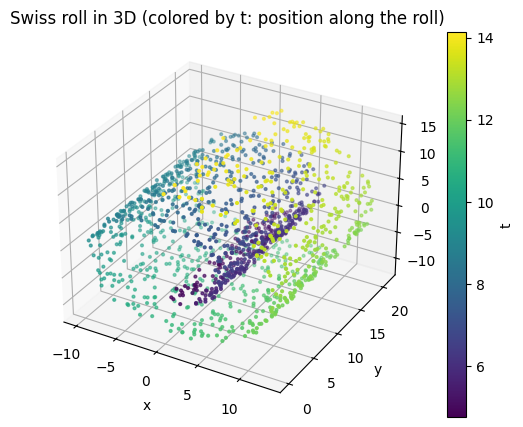

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, s=4, cmap="viridis")
ax.set_title("Swiss roll in 3D (colored by t: position along the roll)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
fig.colorbar(p, ax=ax, label="t")
plt.show()

In [ ]:
X_scaled = StandardScaler().fit_transform(X)
print("Scaled mean:", X_scaled.mean(axis=0))
print("Scaled std :", X_scaled.std(axis=0))

Scaled mean: [5.92118946e-18 9.47390314e-18 1.89478063e-17]
Scaled std : [1. 1. 1.]


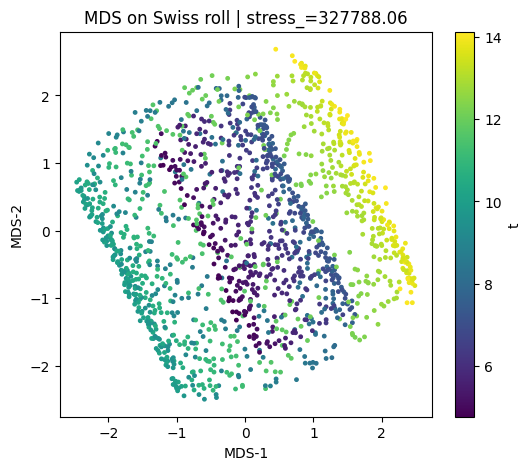

In [ ]:
mds = MDS(
    n_components=2,
    n_init=4,
    max_iter=300,
    random_state=42,
    normalized_stress="auto"
)
X_mds = mds.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_mds[:, 0], X_mds[:, 1], c=t, s=6, cmap="viridis")
plt.title(f"MDS on Swiss roll | stress_={mds.stress_:.2f}")
plt.xlabel("MDS-1"); plt.ylabel("MDS-2")
plt.colorbar(label="t")
plt.show()

*Demonstrates the limitation: if the structure is curved, preserving all Euclidean distances globally in 2D is impossible without distortion.
*In practice: MDS may hide manifold ordering even if data has it.

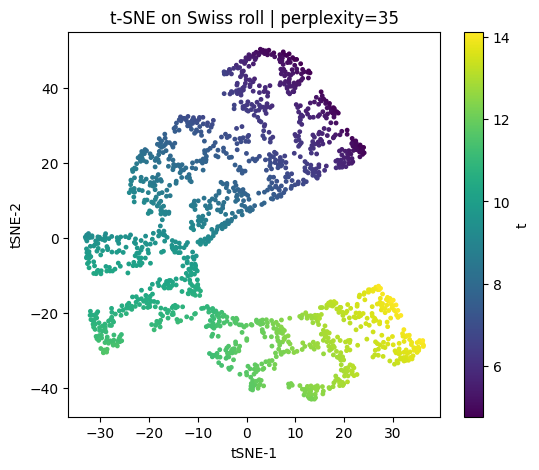

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=35,
    learning_rate="auto",
    init="pca",
    random_state=42
)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=t, s=6, cmap="viridis")
plt.title("t-SNE on Swiss roll | perplexity=35")
plt.xlabel("tSNE-1"); plt.ylabel("tSNE-2")
plt.colorbar(label="t")
plt.show()

* For manifold-like data, t-SNE is often a better exploratory tool:
it reveals continuous structure and neighborhoods
* Great for diagnosing representation learning: “did my embedding organize samples smoothly?”

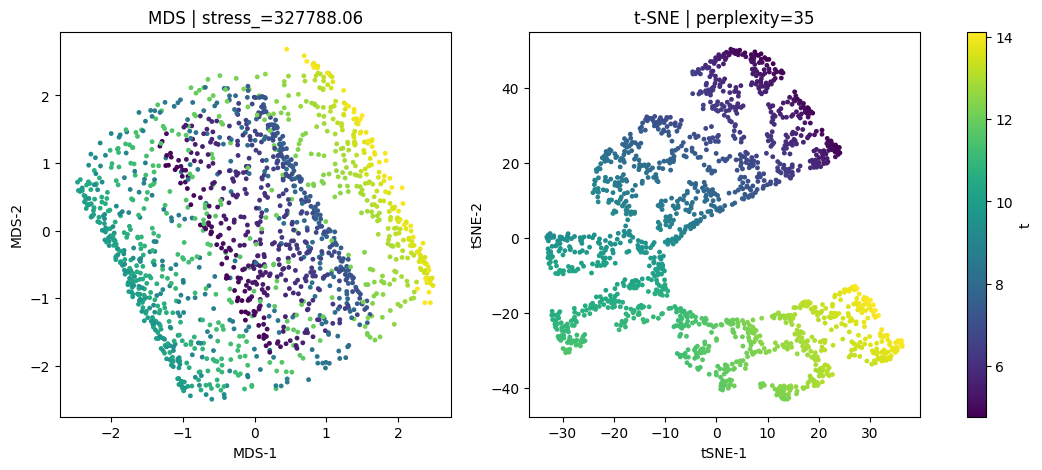

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sc0 = ax[0].scatter(X_mds[:, 0], X_mds[:, 1], c=t, s=6, cmap="viridis")
ax[0].set_title(f"MDS | stress_={mds.stress_:.2f}")
ax[0].set_xlabel("MDS-1"); ax[0].set_ylabel("MDS-2")

sc1 = ax[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=t, s=6, cmap="viridis")
ax[1].set_title("t-SNE | perplexity=35")
ax[1].set_xlabel("tSNE-1"); ax[1].set_ylabel("tSNE-2")

fig.colorbar(sc1, ax=ax, label="t", fraction=0.025)
plt.show()

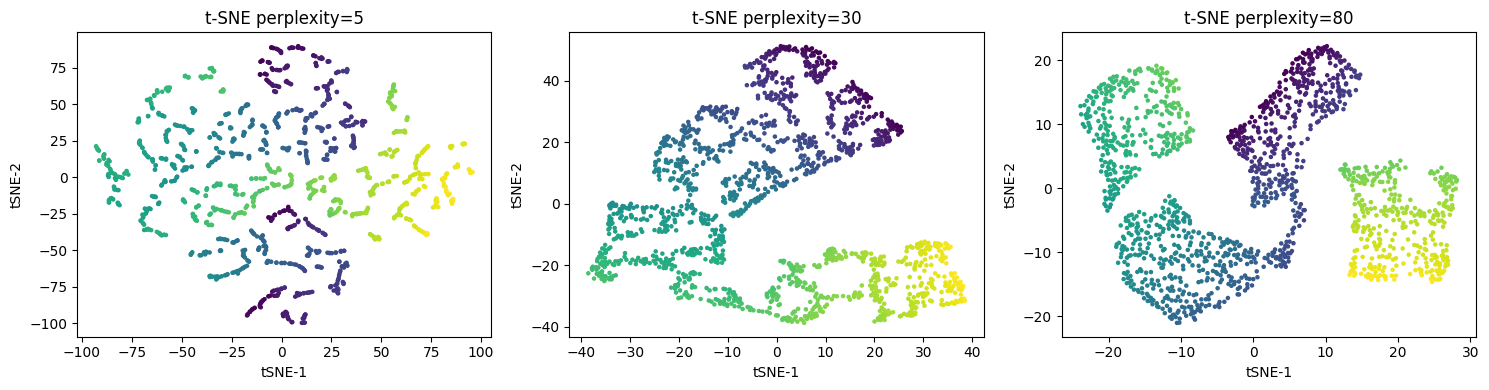

In [ ]:
perplexities = [5, 30, 80]

fig, axes = plt.subplots(1, len(perplexities), figsize=(15, 4))

for ax, p in zip(axes, perplexities):
    tsne = TSNE(
        n_components=2,
        perplexity=p,
        learning_rate="auto",
        init="pca",
        random_state=42
    )
    X_t = tsne.fit_transform(X_scaled)
    ax.scatter(X_t[:, 0], X_t[:, 1], c=t, s=5, cmap="viridis")
    ax.set_title(f"t-SNE perplexity={p}")
    ax.set_xlabel("tSNE-1"); ax.set_ylabel("tSNE-2")

plt.tight_layout()
plt.show()